In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
d0 = pd.read_csv(r"c:\Users\taylorhearn\Dropbox\Shared_With_Me\ROCKi_experiments\c3_actin_analysis_12G10_live_incubation\actin_upreg_results\actin_upreg_d0\acinar_results_membrane_upregulation.csv")

In [54]:
d7 = pd.read_csv(r"c:\Users\taylorhearn\Dropbox\Shared_With_Me\ROCKi_experiments\c3_actin_analysis_12G10_live_incubation\actin_upreg_results\actin_upreg_d7\acinar_results_membrane_upregulation.csv")

In [55]:
df = pd.concat([d0, d7], ignore_index=True)

In [56]:
d7.columns

Index(['acinus_volume_um3', 'acinus_roundness', 'membrane_edge_shell_median',
       'membrane_inner_shell_median', 'membrane_edge_to_inner_ratio',
       'edge_shell_volume_um3', 'inner_shell_volume_um3',
       'protein_exterior_shell_median',
       'protein_exterior_to_membrane_edge_ratio',
       'protein_exterior_to_membrane_inner_ratio', 'protein_edge_shell_median',
       'protein_edge_to_membrane_edge_ratio',
       'protein_edge_to_membrane_inner_ratio', 'exterior_shell_volume_um3',
       'flag', 'filename', 'well', 'day', 'cell_type', 'condition',
       'treatment', 'image_type'],
      dtype='str')

In [57]:
df.columns

Index(['acinus_volume_um3', 'acinus_roundness', 'membrane_edge_shell_median',
       'membrane_inner_shell_median', 'membrane_edge_to_inner_ratio',
       'edge_shell_volume_um3', 'inner_shell_volume_um3',
       'protein_exterior_shell_median',
       'protein_exterior_to_membrane_edge_ratio',
       'protein_exterior_to_membrane_inner_ratio', 'protein_edge_shell_median',
       'protein_edge_to_membrane_edge_ratio',
       'protein_edge_to_membrane_inner_ratio', 'exterior_shell_volume_um3',
       'flag', 'filename', 'well', 'day', 'cell_type', 'condition',
       'treatment', 'image_type'],
      dtype='str')

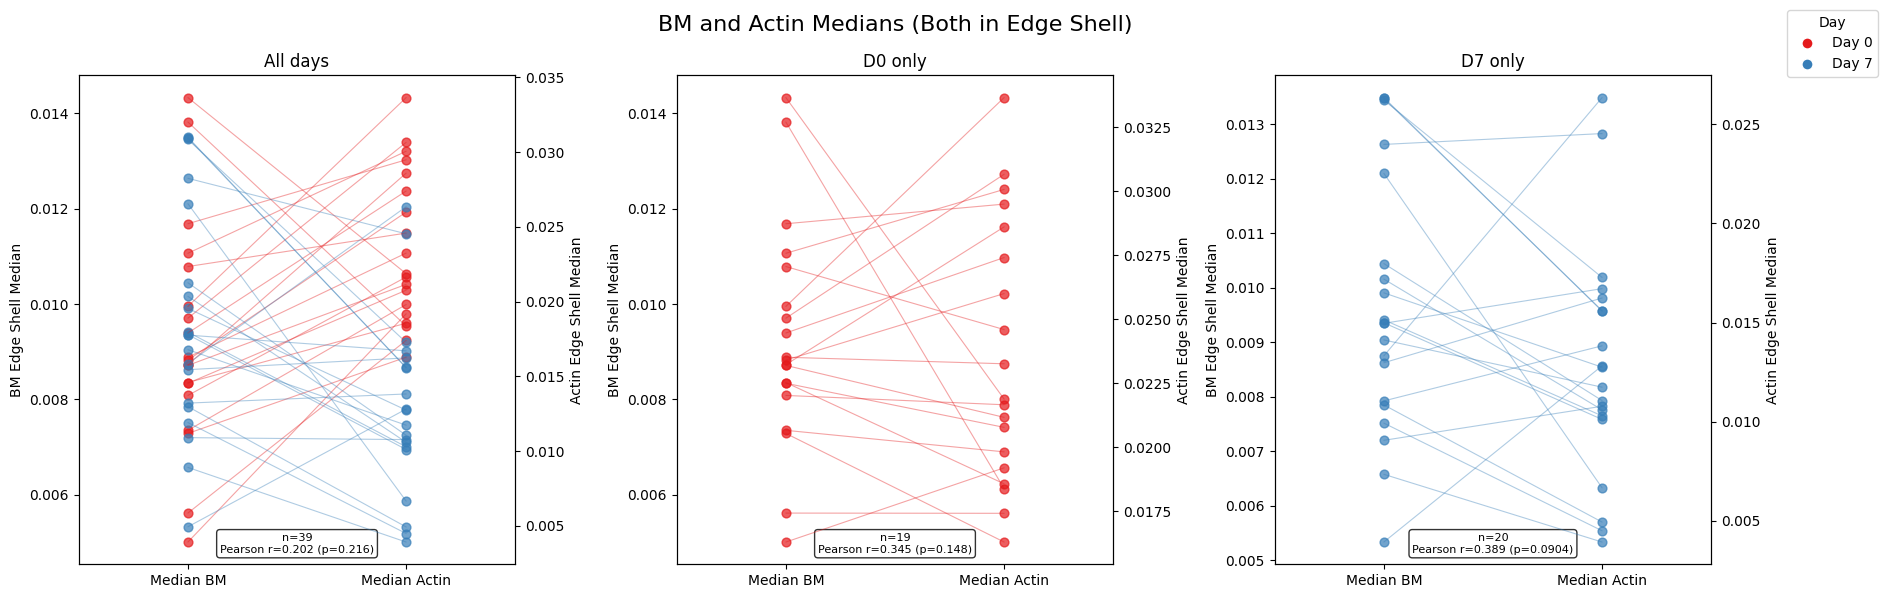

In [61]:

from matplotlib.patches import ConnectionPatch
from scipy import stats

palette = sns.color_palette("Set1", n_colors=df["day"].nunique())
day_colors = {d: palette[i] for i, d in enumerate(sorted(df["day"].unique()))}

subsets = [("All days", df), ("D0 only", df[df["day"] == 0]), ("D7 only", df[df["day"] == 7])]

fig, axes_left = plt.subplots(ncols=3, figsize=(18, 6))

for idx, (title, sub_df) in enumerate(subsets):
    ax_left = axes_left[idx]
    ax_right = ax_left.twinx()

    for _, row in sub_df.iterrows():
        left_val = row["protein_edge_shell_median"]
        right_val = row["membrane_edge_shell_median"]
        color = day_colors[row["day"]]

        ax_left.scatter(0, left_val, color=color, s=40, alpha=0.7, zorder=3)
        ax_right.scatter(1, right_val, color=color, s=40, alpha=0.7, zorder=3)

        con = ConnectionPatch(
            xyA=(0, left_val), coordsA=ax_left.transData,
            xyB=(1, right_val), coordsB=ax_right.transData,
            color=color, alpha=0.4, linewidth=0.8,
        )
        fig.add_artist(con)

    ax_left.set_xlim(-0.5, 1.5)
    ax_right.set_xlim(-0.5, 1.5)
    ax_left.set_xticks([0, 1])
    ax_left.set_xticklabels(["Median BM", "Median Actin"])
    ax_left.set_ylabel("BM Edge Shell Median")
    ax_right.set_ylabel("Actin Edge Shell Median")

    # Stats for this subset
    x = sub_df["protein_edge_shell_median"].dropna()
    y = sub_df["membrane_edge_shell_median"].dropna()
    common = x.index.intersection(y.index)
    if len(common) >= 3:
        r, p = stats.pearsonr(x[common], y[common])
        stat_text = f"n={len(common)}\nPearson r={r:.3f} (p={p:.3g})"
    else:
        stat_text = f"n={len(common)} (too few for stats)"
    ax_left.text(0.5, 0.02, stat_text, transform=ax_left.transAxes,
                 ha="center", va="bottom", fontsize=8,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax_left.set_title(title)

# Shared legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=f"Day {d}")
           for d, c in day_colors.items()]
fig.legend(handles=handles, title="Day", loc="upper right", bbox_to_anchor=(1.05, 1))
plt.suptitle("BM and Actin Medians (Both in Edge Shell)", fontsize=16)
plt.tight_layout()
plt.show()


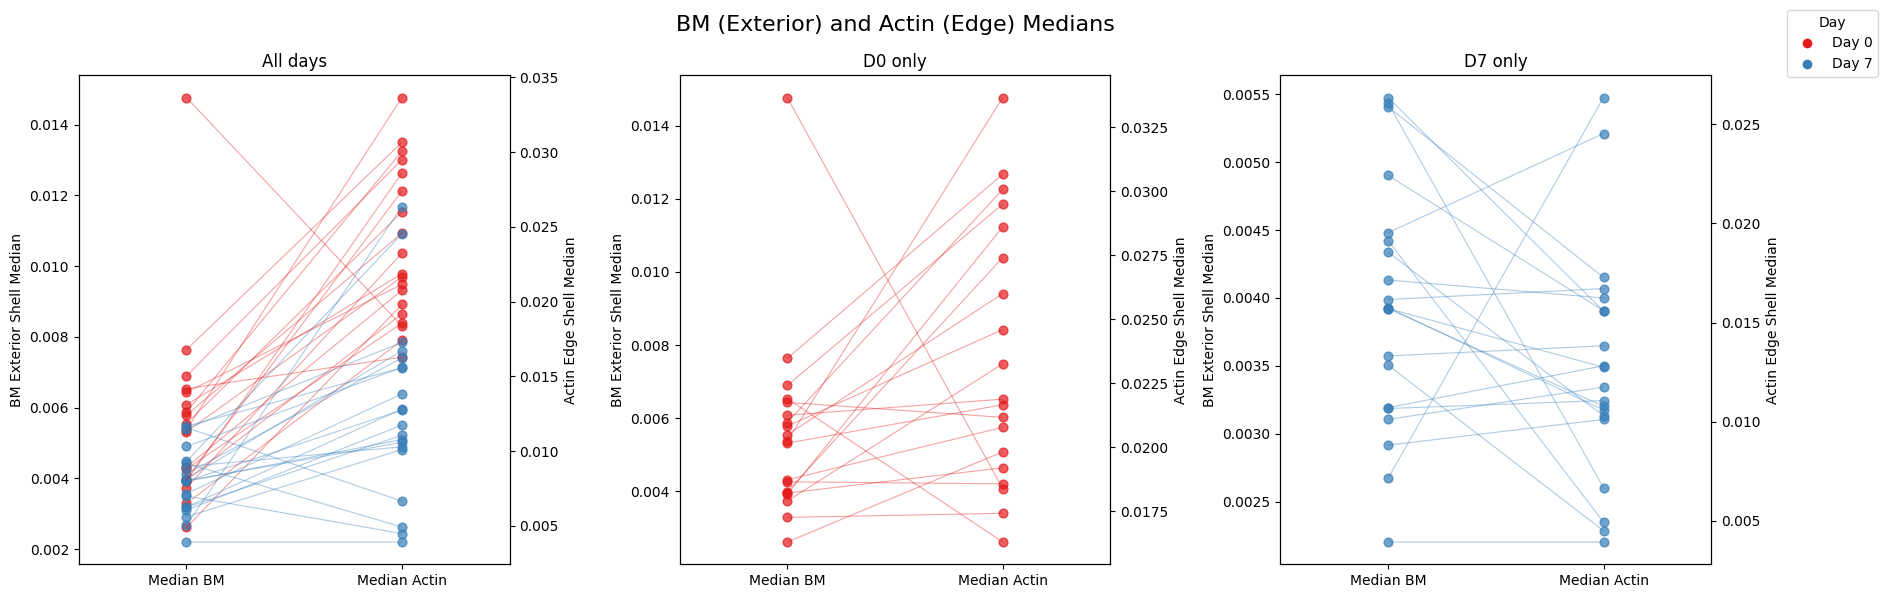

In [ ]:


palette = sns.color_palette("Set1", n_colors=df["day"].nunique())
day_colors = {d: palette[i] for i, d in enumerate(sorted(df["day"].unique()))}

subsets = [("All days", df), ("D0 only", df[df["day"] == 0]), ("D7 only", df[df["day"] == 7])]

fig, axes_left = plt.subplots(ncols=3, figsize=(18, 6))

for idx, (title, sub_df) in enumerate(subsets):
    ax_left = axes_left[idx]
    ax_right = ax_left.twinx()

    for _, row in sub_df.iterrows():
        left_val = row["protein_exterior_shell_median"]
        right_val = row["membrane_edge_shell_median"]
        color = day_colors[row["day"]]

        ax_left.scatter(0, left_val, color=color, s=40, alpha=0.7, zorder=3)
        ax_right.scatter(1, right_val, color=color, s=40, alpha=0.7, zorder=3)

        con = ConnectionPatch(
            xyA=(0, left_val), coordsA=ax_left.transData,
            xyB=(1, right_val), coordsB=ax_right.transData,
            color=color, alpha=0.4, linewidth=0.8,
        )
        fig.add_artist(con)

    ax_left.set_xlim(-0.5, 1.5)
    ax_right.set_xlim(-0.5, 1.5)
    ax_left.set_xticks([0, 1])
    ax_left.set_xticklabels(["Median BM", "Median Actin"])
    ax_left.set_ylabel("BM Exterior Shell Median")
    ax_right.set_ylabel("Actin Edge Shell Median")
    ax_left.set_title(title)

# Shared legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=f"Day {d}")
           for d, c in day_colors.items()]
fig.legend(handles=handles, title="Day", loc="upper right", bbox_to_anchor=(1.05, 1))
plt.suptitle("BM (Exterior) and Actin (Edge) Medians", fontsize=16)

plt.tight_layout()
plt.show()


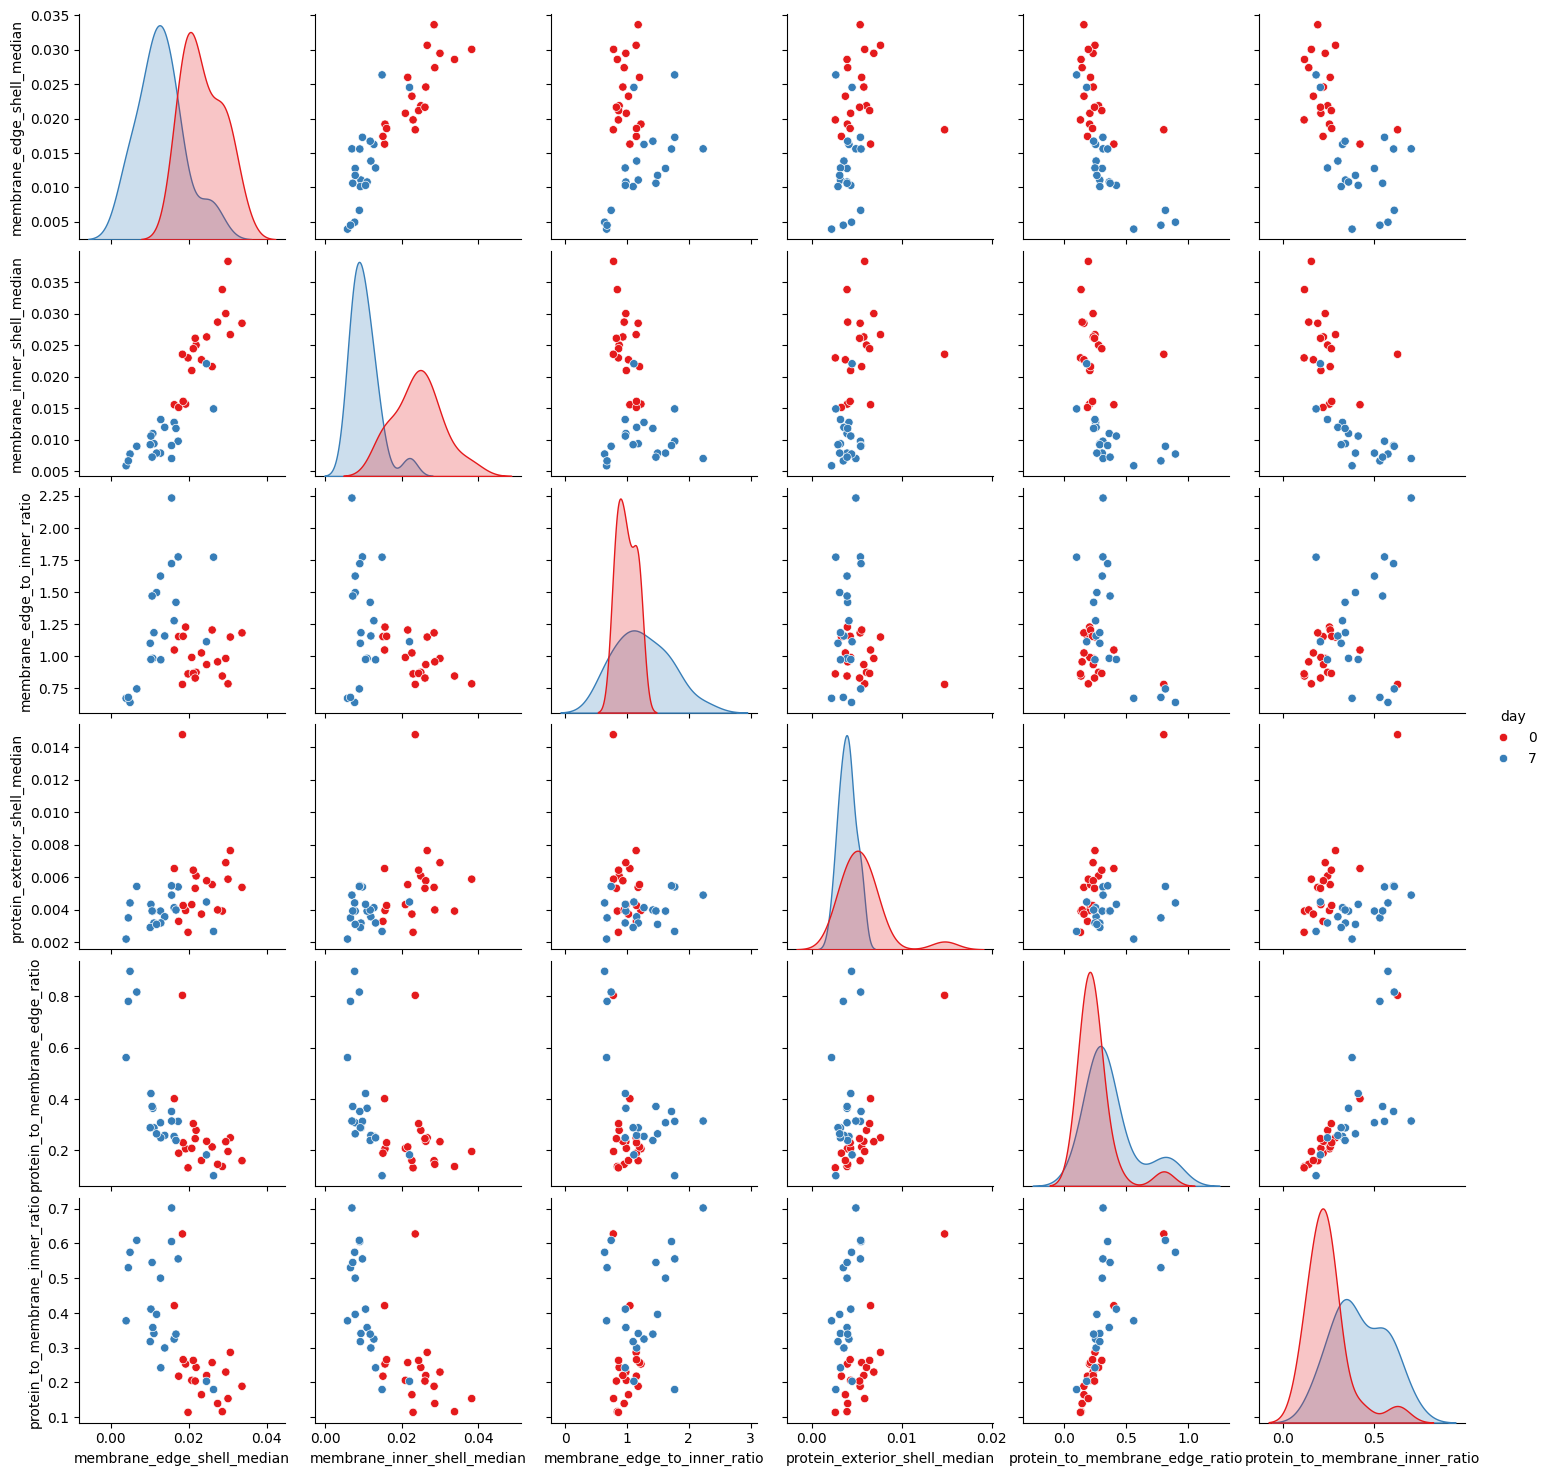

In [25]:
sns.pairplot(data=df, vars=['membrane_edge_shell_median',
       'membrane_inner_shell_median', 'membrane_edge_to_inner_ratio',
       'protein_exterior_shell_median', 'protein_to_membrane_edge_ratio',
       'protein_to_membrane_inner_ratio'], hue="day", palette=day_colors)

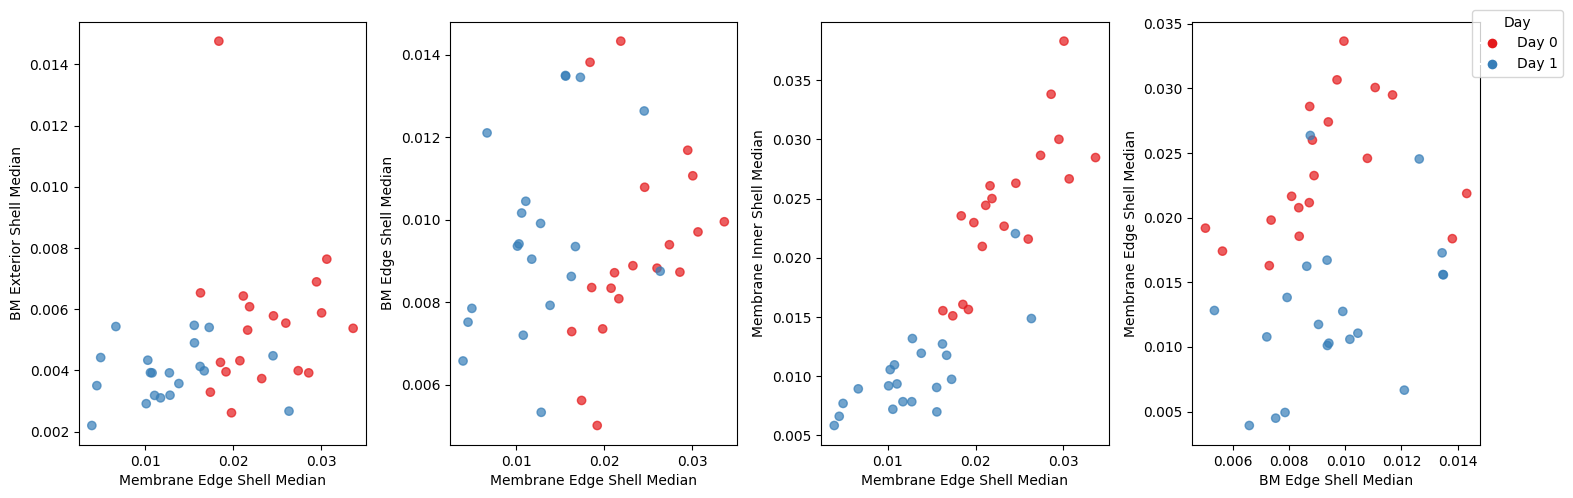

In [15]:

fig, ax = plt.subplots(ncols = 4, figsize=(15, 5))

ax[0].scatter(df["membrane_edge_shell_median"], df["protein_exterior_shell_median"], c=df["day"].map(day_colors), alpha=0.7)
ax[0].set_xlabel("Membrane Edge Shell Median")
ax[0].set_ylabel("BM Exterior Shell Median")



ax[1].scatter(df["membrane_edge_shell_median"], df["protein_edge_shell_median"], c=df["day"].map(day_colors), alpha=0.7)
ax[1].set_xlabel("Membrane Edge Shell Median")
ax[1].set_ylabel("BM Edge Shell Median")

ax[2].scatter(df["membrane_edge_shell_median"], df["membrane_inner_shell_median"], c=df["day"].map(day_colors), alpha=0.7)
ax[2].set_xlabel("Membrane Edge Shell Median")
ax[2].set_ylabel("Membrane Inner Shell Median")

ax[3].scatter(df["protein_edge_shell_median"], df["membrane_edge_shell_median"], c=df["day"].map(day_colors), alpha=0.7)
ax[3].set_xlabel("BM Edge Shell Median")
ax[3].set_ylabel("Membrane Edge Shell Median")

# Shared legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=f"Day {d}")
           for d, c in day_colors.items()]
fig.legend(handles=handles, title="Day", loc="upper right", bbox_to_anchor=(1.05, 1))
plt.tight_layout()


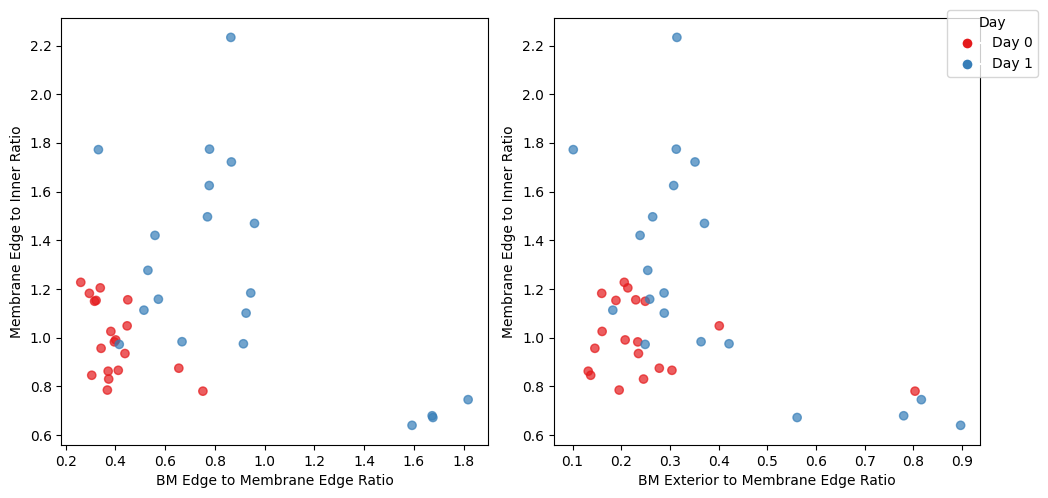

In [21]:

fig, ax = plt.subplots(ncols = 2, figsize=(10, 5))

ax[0].scatter(df["protein_edge_to_membrane_edge_ratio"], df["membrane_edge_to_inner_ratio"], c=df["day"].map(day_colors), alpha=0.7)
ax[0].set_xlabel("BM Edge to Membrane Edge Ratio")
ax[0].set_ylabel("Membrane Edge to Inner Ratio")


ax[1].scatter(df["protein_exterior_to_membrane_edge_ratio"], df["membrane_edge_to_inner_ratio"], c=df["day"].map(day_colors), alpha=0.7)
ax[1].set_xlabel("BM Exterior to Membrane Edge Ratio")
ax[1].set_ylabel("Membrane Edge to Inner Ratio")

# Shared legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=f"Day {d}")
           for d, c in day_colors.items()]
fig.legend(handles=handles, title="Day", loc="upper right", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
